In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df = pd.read_excel('Food Security.xlsx')
df.head()

,Country,Year,Total Population,Agricultural Land (sq. km),Agricultural Land (sq. km) %age Change,Agricultural Land Per Capita (ha/person,Population Growth (Annual %),Pressure Gap,Population Index,Agricultural Land Index,Agricultural Land Per Capita Index
0,Pakistan,1991,120060406,352700,0.181787,0.293769,3.306453,3.124666,100.000000,100.000000,100.000000
1,Pakistan,1992,123546848,353800,0.311880,0.286369,2.862542,2.550662,102.903907,100.311880,97.481119
2,Pakistan,1993,127020117,357500,1.045789,0.281451,2.772506,1.726717,105.796841,101.360930,95.807142
3,Pakistan,1994,130748083,357900,0.111888,0.273733,2.892697,2.780808,108.901916,101.474341,93.179573
4,Pakistan,1995,134582253,360260,0.659402,0.267688,2.890312,2.230910,112.095451,102.143465,91.121865


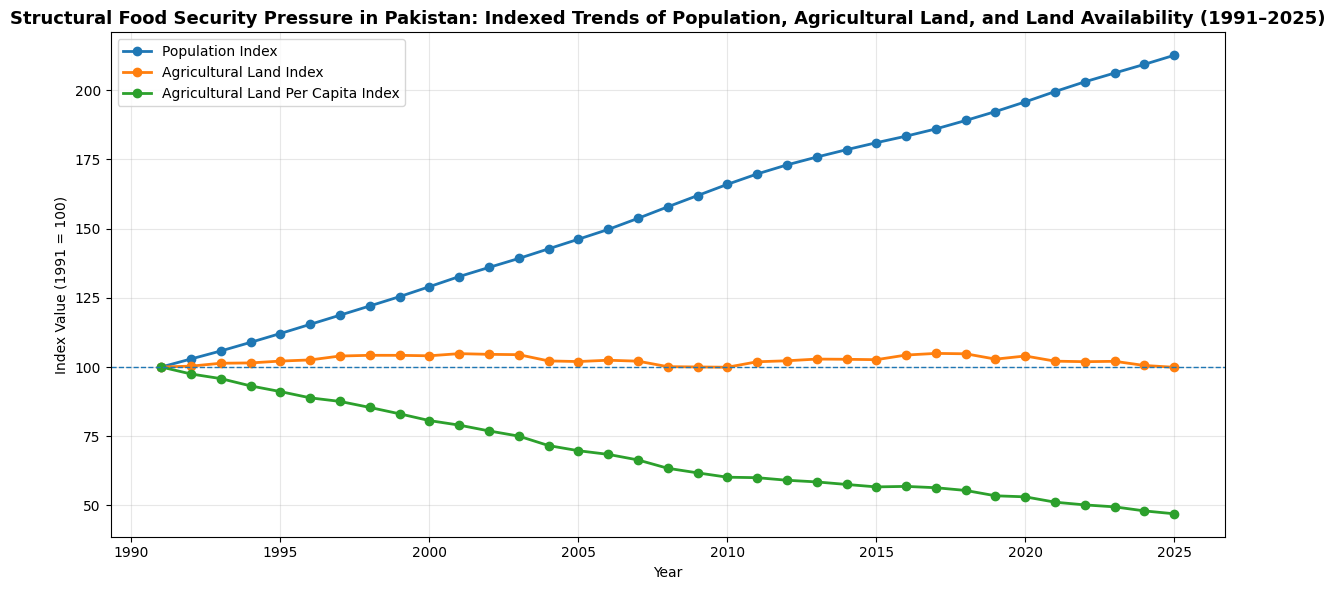

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Load dataset
file_path = "Food Security.xlsx"
df = pd.read_excel(file_path)

# Clean column names because Excel sometimes has hidden spaces
df.columns = df.columns.str.replace('\xa0', ' ', regex=False).str.strip()

# Rename columns for easier use
df = df.rename(columns={
    "Total Population": "Population",
    "Agricultural Land (sq. km)": "Agricultural_Land",
    "Agricultural Land Per Capita (ha/person": "Agri_Land_Per_Capita"
})

# Sort data by year
df = df.sort_values("Year")

# Calculate indices using 1991 as base year
base_year = 1991

base_population = df.loc[df["Year"] == base_year, "Population"].iloc[0]
base_land = df.loc[df["Year"] == base_year, "Agricultural_Land"].iloc[0]
base_land_pc = df.loc[df["Year"] == base_year, "Agri_Land_Per_Capita"].iloc[0]

df["Population Index (1991 = 100)"] = (df["Population"] / base_population) * 100
df["Agricultural Land Index (1991 = 100)"] = (df["Agricultural_Land"] / base_land) * 100
df["Agricultural Land Per Capita Index (1991 = 100)"] = (df["Agri_Land_Per_Capita"] / base_land_pc) * 100

# Plot
plt.figure(figsize=(12, 6))

plt.plot(
    df["Year"],
    df["Population Index (1991 = 100)"],
    marker="o",
    linewidth=2,
    label="Population Index"
)

plt.plot(
    df["Year"],
    df["Agricultural Land Index (1991 = 100)"],
    marker="o",
    linewidth=2,
    label="Agricultural Land Index"
)

plt.plot(
    df["Year"],
    df["Agricultural Land Per Capita Index (1991 = 100)"],
    marker="o",
    linewidth=2,
    label="Agricultural Land Per Capita Index"
)

# Add base year reference line
plt.axhline(y=100, linestyle="--", linewidth=1)

# Titles and labels
plt.title(
    "Structural Food Security Pressure in Pakistan: Indexed Trends of Population, Agricultural Land, and Land Availability (1991–2025)",
    fontsize=13,
    fontweight="bold"
)

plt.xlabel("Year")
plt.ylabel("Index Value (1991 = 100)")

plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()

# Save visual as JPEG at 300 DPI
plt.savefig(
    "food_security_indexed_trends.jpeg",
    format="jpeg",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# Download file if using Google Colab
try:
    from google.colab import files
    files.download("food_security_indexed_trends.jpeg")
except:
    print("JPEG saved as: food_security_indexed_trends.jpeg")

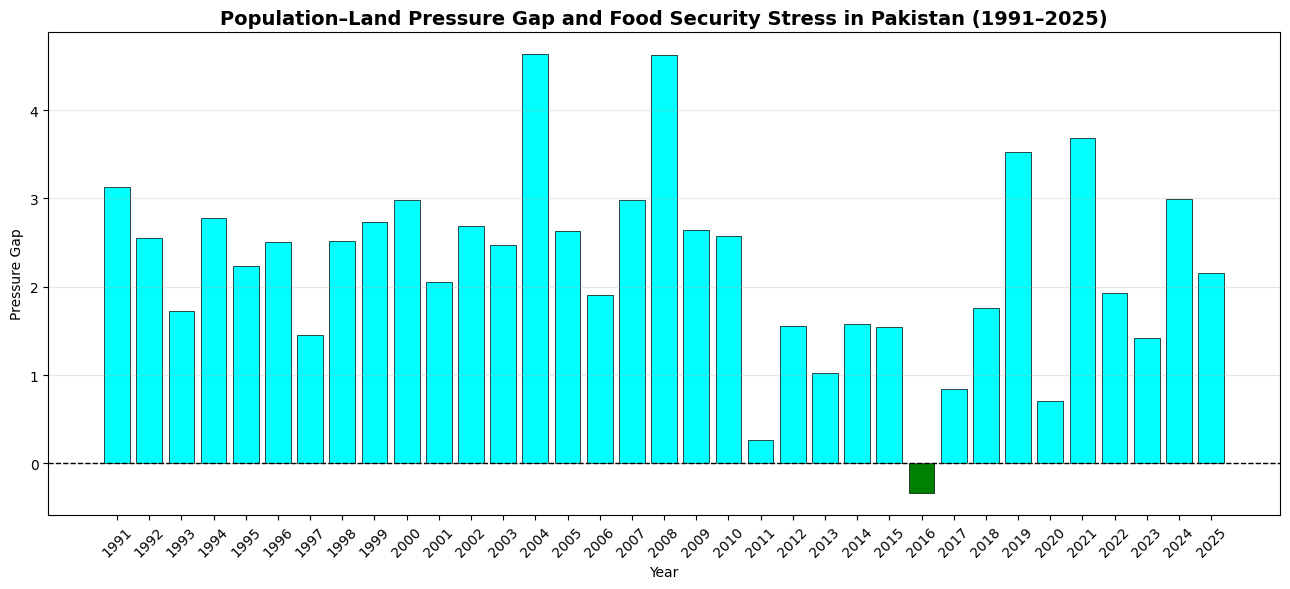

Top 5 Food Security Stress Years Based on Pressure Gap:
    Year  Pressure_Gap
13  2004      4.631383
17  2008      4.620899
30  2021      3.683740
28  2019      3.529340
0   1991      3.124666


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Load dataset
file_path = "Food Security.xlsx"
df = pd.read_excel(file_path)

# Clean column names because Excel sometimes has hidden spaces
df.columns = df.columns.str.replace('\xa0', ' ', regex=False).str.strip()

# Rename Pressure Gap column for easier use
df = df.rename(columns={
    "Pressure Gap": "Pressure_Gap"
})

# Sort data by year
df = df.sort_values("Year")

# Make sure Pressure Gap is numeric
df["Pressure_Gap"] = pd.to_numeric(df["Pressure_Gap"], errors="coerce")

# Drop missing values if any
df = df.dropna(subset=["Year", "Pressure_Gap"])

# Create bar colors
# Positive gap = pressure/stress
# Negative gap = relief
bar_colors = [
    "cyan" if value > 0 else "green" if value < 0 else "gray"
    for value in df["Pressure_Gap"]
]

# Plot
plt.figure(figsize=(13, 6))

plt.bar(
    df["Year"],
    df["Pressure_Gap"],
    color=bar_colors,
    edgecolor="black",
    linewidth=0.5
)

# Add zero reference line
plt.axhline(y=0, color="black", linestyle="--", linewidth=1)

# Titles and labels
plt.title(
    "Population–Land Pressure Gap and Food Security Stress in Pakistan (1991–2025)",
    fontsize=14,
    fontweight="bold"
)

plt.xlabel("Year")
plt.ylabel("Pressure Gap")

# Add grid
plt.grid(axis="y", alpha=0.3)

# Improve x-axis readability
plt.xticks(df["Year"], rotation=45)

plt.tight_layout()

# Save visual as JPEG at 300 DPI
plt.savefig(
    "population_land_pressure_gap.jpeg",
    format="jpeg",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# Show top 5 high-pressure years
top_pressure_years = df.sort_values("Pressure_Gap", ascending=False).head(5)

print("Top 5 Food Security Stress Years Based on Pressure Gap:")
print(top_pressure_years[["Year", "Pressure_Gap"]])

# Download file if using Google Colab
try:
    from google.colab import files
    files.download("population_land_pressure_gap.jpeg")
except:
    print("JPEG saved as: population_land_pressure_gap.jpeg")

Period-Wise Food Security Pressure Summary:
           Avg Population Growth  Avg Agricultural Land Growth  \
Period                                                           
1991–2000                   2.88                          0.42   
2001–2010                   2.52                         -0.40   
2011–2017                   1.63                          0.70   
2018–2025                   1.67                         -0.61   

           Avg Pressure Gap  
Period                       
1991–2000              2.46  
2001–2010              2.92  
2011–2017              0.93  
2018–2025              2.27  


<Figure size 1100x600 with 0 Axes>

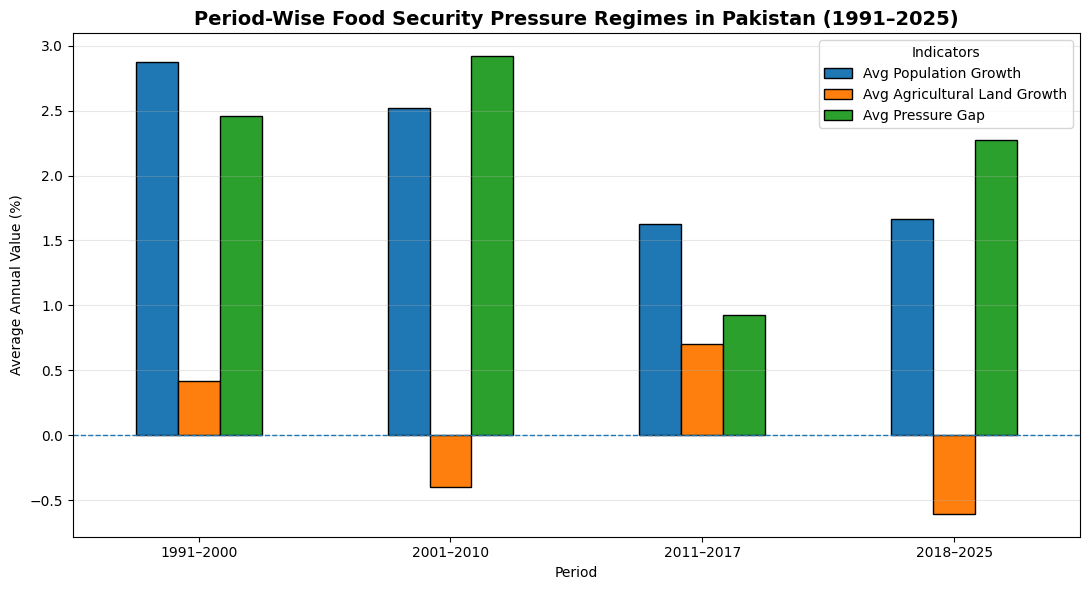

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Load dataset
file_path = "Food Security.xlsx"
df = pd.read_excel(file_path)

# Clean column names
df.columns = df.columns.str.replace('\xa0', ' ', regex=False).str.strip()

# Rename columns for easier use
df = df.rename(columns={
    "Population Growth (Annual %)": "Population_Growth",
    "Agricultural Land (sq. km) %age Change": "Agricultural_Land_Growth",
    "Pressure Gap": "Pressure_Gap"
})

# Sort by year
df = df.sort_values("Year")

# Create period groups
def assign_period(year):
    if 1991 <= year <= 2000:
        return "1991–2000"
    elif 2001 <= year <= 2010:
        return "2001–2010"
    elif 2011 <= year <= 2017:
        return "2011–2017"
    elif 2018 <= year <= 2025:
        return "2018–2025"
    else:
        return None

df["Period"] = df["Year"].apply(assign_period)

# Remove rows outside selected periods, if any
df = df.dropna(subset=["Period"])

# Calculate period-wise averages
period_summary = df.groupby("Period")[[
    "Population_Growth",
    "Agricultural_Land_Growth",
    "Pressure_Gap"
]].mean()

# Rename columns for graph readability
period_summary = period_summary.rename(columns={
    "Population_Growth": "Avg Population Growth",
    "Agricultural_Land_Growth": "Avg Agricultural Land Growth",
    "Pressure_Gap": "Avg Pressure Gap"
})

# Print summary table
print("Period-Wise Food Security Pressure Summary:")
print(period_summary.round(2))

# Plot grouped bar chart
plt.figure(figsize=(11, 6))

period_summary.plot(
    kind="bar",
    figsize=(11, 6),
    edgecolor="black"
)

plt.title(
    "Period-Wise Food Security Pressure Regimes in Pakistan (1991–2025)",
    fontsize=14,
    fontweight="bold"
)

plt.xlabel("Period")
plt.ylabel("Average Annual Value (%)")
plt.xticks(rotation=0)
plt.axhline(y=0, linestyle="--", linewidth=1)
plt.grid(axis="y", alpha=0.3)
plt.legend(title="Indicators")

plt.tight_layout()

# Save visual as JPEG at 300 DPI
plt.savefig(
    "period_wise_food_security_pressure_regimes.jpeg",
    format="jpeg",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# Download file if using Google Colab
try:
    from google.colab import files
    files.download("period_wise_food_security_pressure_regimes.jpeg")
except:
    print("JPEG saved as: period_wise_food_security_pressure_regimes.jpeg")